# RECONSTRUCCIÓN LPA 1970
*Esta sección fue inyectada automáticamente para asegurar la consistencia territorial.*

In [128]:
import pandas as pd
import numpy as np
import unicodedata
import re
import os
import warnings

warnings.filterwarnings('ignore')

In [134]:
PATH_MAPPING = '/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/mapping_1970_2024.csv'
PATH_POBLACION = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/población/Consolidado informacion censos historicos .xlsx'
PATH_COMERCIO = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/Flujos de comercio externso/flujos_de_comercio_1970.dta'
PATH_DEFLACTOR = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/Flujos de comercio externso/API_NY.GDP.DEFL.KD.ZG_DS2_es_excel_v2_5550.xls'
PATH_GDPPC = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/Flujos de comercio externso/gdp-per-capita-maddison-project-database/gdp-per-capita-maddison-project-database.csv'

BASE_DISTANCIA = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/'

PATHS_MATRICES = {
    1970: BASE_DISTANCIA + 'matriz_OD_1970.csv',
    1980: BASE_DISTANCIA + 'matriz_OD_1980.csv',
    2024: BASE_DISTANCIA + 'matriz_OD_actual.csv',
}

PATH_OUT_DIR = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/'

THETA_BASE = 4

# Puertos EMPORCHI y sus poblaciones censales de 1970 (para imputación de comercio)
PUERTOS = {
    'VALPARAISO': 254812,
    'SAN ANTONIO': 53406,
    'ANTOFAGASTA': 127967,
    'SAN VICENTE': 26796,  
    'IQUIQUE': 64997,
    'PUERTO MONTT': 81842,
    'PUNTA ARENAS': 65836,
    'ARICA': 92523,
    'COQUIMBO': 61423,
    'VALDIVIA': 92055
}


In [135]:
# Alias de ortografía: la OD matrix usa variantes diferentes al consolidado
# poblacional o al mapping. Estos alias canonizan los nombres.
SPELLING_ALIASES = {
    'AYSEN': 'AISEN',
    'COYHAIQUE': 'COIHAIQUE',
    'TREHUACO': 'TREGUACO',
    'PAIHUANO': 'PAIGUANO',
}


def normalizar(txt):
    """Normaliza un nombre de comuna: mayúsculas, sin acentos, sin espacios extra."""
    if pd.isna(txt):
        return None
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'\s+', ' ', txt).strip()
    # Aplicar alias de ortografía
    return SPELLING_ALIASES.get(txt, txt)


def calcular_market_access(df_od,
                           theta=3.8,
                           col_origin='origin_COMUNA',
                           col_dest='destination_COMUNA',
                           col_time='time_min',
                           col_pop='destination_pop_1970',
                           min_time=1.0):
    """
    Calcula MA_o = sum_{d != o} (tau_od)^-theta * N_d
    Versión sin aglomeraciones.
    """
    df = df_od.copy()

    # 1. Excluir diagonal (comuna no comercia consigo misma)
    df['_norm_o'] = df[col_origin].apply(normalizar)
    df['_norm_d'] = df[col_dest].apply(normalizar)
    df = df[df['_norm_o'] != df['_norm_d']].copy()

    # 2. Solo destinos con mercado potencial
    df = df[df[col_pop] > 0]

    # 3. Cálculo de accesibilidad
    df[col_time] = df[col_time].clip(lower=min_time) / 3600  # minutos → horas
    df['contribucion'] = df[col_pop] * (df[col_time] ** (-theta))

    # 4. Agregación por origen
    ma_df = (df.groupby(col_origin)['contribucion']
               .sum()
               .reset_index()
               .rename(columns={col_origin: 'comuna', 'contribucion': 'MA'}))

    # 5. Transformación log
    ma_df['log_MA'] = np.log(ma_df['MA'])

    return ma_df

In [136]:
## Revisión mapping comunas madre-hijas

df_map = pd.read_csv(PATH_MAPPING)

# Asegurar normalización
df_map['mother_1970_norm'] = df_map['mother_1970'].apply(normalizar)
df_map['daughter_2024_norm'] = df_map['daughter_2024'].apply(normalizar)

# Identificar comunas sin madre (huérfanas en 2024)
huerfanas = df_map[df_map['mother_1970_norm'].isna()]
print(f"\n⚠️  Comunas 2024 sin madre 1970 ({len(huerfanas)}):")
for _, row in huerfanas.iterrows():
    print(f"   - {row['daughter_2024']}")

# Identificar comunas madre con múltiples hijas
mother_counts = df_map.dropna(subset=['mother_1970_norm']).groupby('mother_1970_norm').size()
multi_hijas = mother_counts[mother_counts > 1].sort_values(ascending=False)
print(f"\n📊 Comunas madre 1970 con múltiples hijas ({len(multi_hijas)}):")
for madre, n_hijas in multi_hijas.items():
    hijas = df_map[df_map['mother_1970_norm'] == madre]['daughter_2024'].tolist()
    print(f"   {madre} ({n_hijas} hijas): {', '.join(hijas)}")

# Comunas 1:1 (no subdivididas)
uno_a_uno = mother_counts[mother_counts == 1]
print(f"\n✅ Comunas 1:1 (no subdivididas): {len(uno_a_uno)}")


⚠️  Comunas 2024 sin madre 1970 (6):
   - Guaitecas
   - Quemchi
   - Talcahuano
   - Quinchao
   - Río Verde
   - Juan Fernández

📊 Comunas madre 1970 con múltiples hijas (44):
   OSORNO (3 hijas): Puyehue, San Juan de la Costa, Osorno
   CONCHALI (3 hijas): Independencia, Huechuraba, Conchalí
   BAKER (3 hijas): O'Higgins, Tortel, Cochrane
   NUNOA (3 hijas): Macul, Ñuñoa, Peñalolén
   MAIPU (3 hijas): Maipú, Cerrillos, Estación Central
   LAS CONDES (3 hijas): Vitacura, Lo Barnechea, Las Condes
   LA GRANJA (3 hijas): San Ramón, La Pintana, La Granja
   SAN MIGUEL (3 hijas): San Miguel, San Joaquín, Pedro Aguirre Cerda
   BARRANCAS (3 hijas): Lo Prado, Pudahuel, Cerro Navia
   CALAMA (3 hijas): Ollagüe, San Pedro de Atacama, Calama
   TUCAPEL (2 hijas): Tucapel, Antuco
   TOLTEN (2 hijas): Teodoro Schmidt, Toltén
   PUERTO MONTT (2 hijas): Puerto Montt, Hualaihué
   PUNITAQUI (2 hijas): Punitaqui, Ovalle
   PUREN (2 hijas): Purén, Contulmo
   VINA DEL MAR (2 hijas): Concón, Viña de

In [137]:
#  REASIGNACIÓN DE POBLACIÓN A COMUNAS MADRE 1970


# Cargar consolidado de censos
df_pob = pd.read_excel(PATH_POBLACION)
df_pob['pob_70'] = pd.to_numeric(df_pob['1970'], errors='coerce').fillna(0)
df_pob['norm_name'] = df_pob['Nombre Comuna'].apply(normalizar)

# Crear lookup de población por comuna 2024 normalizada
pob_lookup = df_pob.groupby('norm_name').agg({
    'pob_70': 'sum',
    'Nombre Region': 'first',
    'Nombre Provincia': 'first',
    'Region': 'first',
}).reset_index()

print(f"\n📋 Comunas en consolidado poblacional: {len(pob_lookup)}")
print(f"   Población total 1970: {pob_lookup['pob_70'].sum():,.0f}")

# Construir población a nivel de comunas madre 1970
# Para cada madre: sumar la población de todas sus hijas
df_map_valid = df_map.dropna(subset=['mother_1970_norm']).copy()

# Merge: mapping + población
df_map_valid = df_map_valid.merge(
    pob_lookup[['norm_name', 'pob_70', 'Nombre Region', 'Nombre Provincia', 'Region']],
    left_on='daughter_2024_norm',
    right_on='norm_name',
    how='left'
)

# Agregar por madre
pop_madre_1970 = df_map_valid.groupby('mother_1970_norm').agg({
    'pob_70': 'sum',                   # Suma de las poblaciones de las hijas
    'Nombre Region': 'first',          # Región (primera hija como referencia)
    'Nombre Provincia': 'first',       # Provincia
    'Region': 'first',
}).reset_index().rename(columns={
    'mother_1970_norm': 'comuna_1970',
    'pob_70': 'poblacion_1970',
})

# Para comunas con múltiples hijas, mostrar cómo se sumó la población
print("\n📊 Reasignación de población (comunas subdivididas):")
for madre in multi_hijas.index:
    hijas_data = df_map_valid[df_map_valid['mother_1970_norm'] == madre][
        ['daughter_2024', 'pob_70']
    ]
    total = hijas_data['pob_70'].sum()
    detalle = " + ".join(
        f"{row['daughter_2024']}({row['pob_70']:,.0f})"
        for _, row in hijas_data.iterrows()
    )
    print(f"   {madre} = {detalle} = {total:,.0f}")

print(f"\n✅ Total comunas madre 1970 con población: {len(pop_madre_1970)}")
print(f"   Población total reconstruida: {pop_madre_1970['poblacion_1970'].sum():,.0f}")


📋 Comunas en consolidado poblacional: 346
   Población total 1970: 8,893,217

📊 Reasignación de población (comunas subdivididas):
   OSORNO = Puyehue(9,866) + San Juan de la Costa(9,522) + Osorno(84,130) = 103,518
   CONCHALI = Independencia(95,723) + Huechuraba(22,217) + Conchalí(117,405) = 235,345
   BAKER = O'Higgins(226) + Tortel(227) + Cochrane(1,694) = 2,147
   NUNOA = Macul(73,111) + Ñuñoa(149,001) + Peñalolén(50,983) = 273,095
   MAIPU = Maipú(44,733) + Cerrillos(34,903) + Estación Central(131,157) = 210,793
   LAS CONDES = Vitacura(40,343) + Lo Barnechea(11,174) + Las Condes(112,590) = 164,107
   LA GRANJA = San Ramón(59,033) + La Pintana(37,994) + La Granja(77,263) = 174,290
   SAN MIGUEL = San Miguel(93,784) + San Joaquín(115,085) + Pedro Aguirre Cerda(141,592) = 350,461
   BARRANCAS = Lo Prado(53,365) + Pudahuel(50,959) + Cerro Navia(83,755) = 188,079
   CALAMA = Ollagüe(911) + San Pedro de Atacama(1,784) + Calama(70,105) = 72,800
   TUCAPEL = Tucapel(11,750) + Antuco(10,0

In [138]:
# Cargar la matriz OD 1970 para detectar qué comunas madre NO tienen rutas
df_od_1970 = pd.read_csv(PATHS_MATRICES[1970])
df_od_1970['norm_origin'] = df_od_1970['origin_COMUNA'].apply(normalizar)
df_od_1970['norm_dest'] = df_od_1970['destination_COMUNA'].apply(normalizar)

comunas_en_od = set(df_od_1970['norm_origin'].dropna().unique())

# Detectar comunas madre 1970 que NO están en la OD matrix
madres_sin_od = []
for _, row in pop_madre_1970.iterrows():
    madre = row['comuna_1970']
    if madre not in comunas_en_od and row['poblacion_1970'] > 0:
        # Verificar si alguna hija SÍ está en la OD
        hijas = df_map_valid[df_map_valid['mother_1970_norm'] == madre]['daughter_2024_norm'].tolist()
        hijas_en_od = [h for h in hijas if h in comunas_en_od]
        if hijas_en_od:
            madres_sin_od.append({
                'madre': madre,
                'poblacion': row['poblacion_1970'],
                'hijas_en_od': hijas_en_od,
                'hijas_total': hijas,
            })

if madres_sin_od:
    print(f"\n⚠️  Comunas madre 1970 SIN rutas propias pero CON hijas en OD ({len(madres_sin_od)}):")
    for caso in madres_sin_od:
        print(f"   {caso['madre']} (pob: {caso['poblacion']:,.0f})")
        print(f"     Hijas en OD: {', '.join(caso['hijas_en_od'])}")
        print(f"     Hijas sin OD: {set(caso['hijas_total']) - set(caso['hijas_en_od'])}")
else:
    print("\n✅ No hay casos especiales tipo BAKER (todas las madres tienen rutas)")


⚠️  Comunas madre 1970 SIN rutas propias pero CON hijas en OD (23):
   AGUAS BLANCAS (pob: 127,967)
     Hijas en OD: ANTOFAGASTA
     Hijas sin OD: set()
   BAHIA INUTIL (pob: 4,241)
     Hijas en OD: PORVENIR
     Hijas sin OD: {'TIMAUKEL'}
   BAKER (pob: 2,147)
     Hijas en OD: TORTEL
     Hijas sin OD: {'COCHRANE', "O'HIGGINS"}
   BARRANCAS (pob: 188,079)
     Hijas en OD: LO PRADO, PUDAHUEL, CERRO NAVIA
     Hijas sin OD: set()
   BELEN (pob: 1,767)
     Hijas en OD: PUTRE
     Hijas sin OD: set()
   CATALINA (pob: 9,372)
     Hijas en OD: TALTAL
     Hijas sin OD: set()
   CERRO CASTILLO (pob: 533)
     Hijas en OD: TORRES DEL PAINE
     Hijas sin OD: set()
   CODPA (pob: 991)
     Hijas en OD: CAMARONES
     Hijas sin OD: set()
   GENERAL CARRERA (pob: 3,601)
     Hijas en OD: CHILE CHICO
     Hijas sin OD: set()
   LA CALERA (pob: 10,194)
     Hijas en OD: HIJUELAS
     Hijas sin OD: set()
   LAGO RANGO (pob: 19,153)
     Hijas en OD: FUTRONO, LAGO RANCO
     Hijas sin OD: se

In [139]:

# Crear diccionario de lookup: hija_norm → madre_norm
hija_a_madre = {}
for _, row in df_map_valid.iterrows():
    hija_a_madre[row['daughter_2024_norm']] = row['mother_1970_norm']

# Diccionario de población madre 1970
pop_madre_dict = dict(zip(pop_madre_1970['comuna_1970'], pop_madre_1970['poblacion_1970']))


def ajustar_matriz_od(df_od, hija_a_madre, pop_madre_dict):
  
    df = df_od.copy()

    # Normalizar nombres
    df['norm_origin'] = df['origin_COMUNA'].apply(normalizar)
    df['norm_dest'] = df['destination_COMUNA'].apply(normalizar)

    # Eliminar filas con NaN en comunas
    df = df.dropna(subset=['norm_origin', 'norm_dest']).copy()

    # Reemplazar hijas por madres
    df['madre_origin'] = df['norm_origin'].map(hija_a_madre).fillna(df['norm_origin'])
    df['madre_dest'] = df['norm_dest'].map(hija_a_madre).fillna(df['norm_dest'])

    # Agregar: cuando múltiples hijas se funden en la misma madre,
    # tomamos el MÍNIMO de tiempo (la ruta más rápida entre las sub-comunas)
    # Esto es equivalente a usar la mejor ruta disponible.
    df_agg = df.groupby(['madre_origin', 'madre_dest']).agg({
        'time_min': 'min',  # Mínimo tiempo entre sub-comunas
    }).reset_index()

    # Renombrar para mantener formato original
    df_agg = df_agg.rename(columns={
        'madre_origin': 'origin_COMUNA',
        'madre_dest': 'destination_COMUNA',
    })

    # Asignar población de la madre destino
    df_agg['destination_pop_1970'] = df_agg['destination_COMUNA'].map(pop_madre_dict).fillna(0)

    return df_agg

In [ ]:
# Imputación de comercio exterior

df_comercio = pd.read_stata(PATH_COMERCIO)
comercio_total_1970 = (df_comercio['importaciones'] + df_comercio['exportaciones']).sum()

df_defl = pd.read_excel(PATH_DEFLACTOR, sheet_name='Data', skiprows=3)
usa_defl = df_defl[df_defl['Country Code'] == 'USA']
factor_deflactor = 1.0
for yr in range(1971, 2012):
    col = str(yr)
    if col in usa_defl.columns:
        rate = usa_defl[col].values[0]
        if not pd.isna(rate):
            factor_deflactor *= (1 + rate / 100)

comercio_total_2011 = comercio_total_1970 * factor_deflactor

df_gdppc = pd.read_csv(PATH_GDPPC)
gdppc_chile = df_gdppc[(df_gdppc['Entity'] == 'Chile') & (df_gdppc['Year'] == 1970)]['GDP per capita'].values[0]

pob_equiv_comercio = (comercio_total_2011 * 1e6) / gdppc_chile
print(f"   Comercio total 1970: {comercio_total_1970:,.2f} M USD")
print(f"   Factor deflactor 1970→2011: {factor_deflactor:.4f}")
print(f"   PIB per cápita Maddison: {gdppc_chile:,.0f}")
print(f"   Población equivalente al comercio: {pob_equiv_comercio:,.0f}")

# Distribuir entre puertos proporcionalmente a su población
pob_total_puertos = sum(PUERTOS.values())
asignacion_puertos = {}
for puerto, pob in PUERTOS.items():
    fraccion = pob / pob_total_puertos
    asignacion_puertos[normalizar(puerto)] = pob_equiv_comercio * fraccion

# Agregar población portuaria al diccionario de poblaciones madre
for puerto_norm, pob_extra in asignacion_puertos.items():
    if puerto_norm in pop_madre_dict:
        pop_madre_dict[puerto_norm] += pob_extra
        print(f"   Puerto {puerto_norm}: +{pob_extra:,.0f} hab. equiv. → total {pop_madre_dict[puerto_norm]:,.0f}")


--- Calculando población equivalente al comercio exterior ---
   Comercio total 1970: 1,334.32 M USD
   Factor deflactor 1970→2011: 4.5313
   PIB per cápita Maddison: 8,195
   Población equivalente al comercio: 737,796
   Puerto VALPARAISO: +203,980 hab. equiv. → total 458,792
   Puerto SAN ANTONIO: +42,752 hab. equiv. → total 96,158
   Puerto SAN VICENTE: +21,450 hab. equiv. → total 48,246
   Puerto IQUIQUE: +52,031 hab. equiv. → total 117,028
   Puerto PUERTO MONTT: +65,515 hab. equiv. → total 152,981
   Puerto ARICA: +74,066 hab. equiv. → total 166,589
   Puerto VALDIVIA: +73,691 hab. equiv. → total 165,746


In [140]:
# Procesar cada matriz
matrices_ajustadas = {}

for anio, path in PATHS_MATRICES.items():
    print(f"\n--- Ajustando matriz OD: Año {anio} ---")
    df_od_raw = pd.read_csv(path)
    print(f"   Filas originales: {len(df_od_raw):,}")
    print(f"   Comunas origen originales: {df_od_raw['origin_COMUNA'].nunique()}")

    df_od_ajustada = ajustar_matriz_od(df_od_raw, hija_a_madre, pop_madre_dict)
    print(f"   Filas ajustadas: {len(df_od_ajustada):,}")
    print(f"   Comunas origen ajustadas: {df_od_ajustada['origin_COMUNA'].nunique()}")

    # Guardar
    out_path = os.path.join(BASE_DISTANCIA, f'matriz_OD_{anio}_comunas1970.csv')
    df_od_ajustada.to_csv(out_path, index=False)
    matrices_ajustadas[anio] = out_path
    print(f"   ✅ Guardada: {os.path.basename(out_path)}")


--- Ajustando matriz OD: Año 1970 ---
   Filas originales: 111,220
   Comunas origen originales: 333
   Filas ajustadas: 80,413
   Comunas origen ajustadas: 284
   ✅ Guardada: matriz_OD_1970_comunas1970.csv

--- Ajustando matriz OD: Año 1980 ---
   Filas originales: 110,556
   Comunas origen originales: 333
   Filas ajustadas: 80,413
   Comunas origen ajustadas: 284
   ✅ Guardada: matriz_OD_1980_comunas1970.csv

--- Ajustando matriz OD: Año 2024 ---
   Filas originales: 111,220
   Comunas origen originales: 333
   Filas ajustadas: 80,413
   Comunas origen ajustadas: 284
   ✅ Guardada: matriz_OD_2024_comunas1970.csv


## Estimación Market Access

In [141]:
# ESTIMACIÓN DE MARKET ACCESS


print("\n" + "=" * 70)
print("COMPONENTE 5: Estimación de Market Access (LPA 1970)")
print("=" * 70)

# Determinar comunas madre con población > 0
comunas_con_pob = set(
    pop_madre_1970[pop_madre_1970['poblacion_1970'] > 0]['comuna_1970'].unique()
)
print(f"\n📋 Comunas madre 1970 con población > 0: {len(comunas_con_pob)}")

resultados = {}

for anio, path in matrices_ajustadas.items():
    print(f"\n--- Estimando Market Access: Año {anio} (θ={THETA_BASE}) ---")

    df_od = pd.read_csv(path)

    # Filtrar: solo orígenes que son comunas madre con población
    df_od['norm_origin'] = df_od['origin_COMUNA'].apply(normalizar)
    df_od_filtrada = df_od[df_od['norm_origin'].isin(comunas_con_pob)].copy()
    df_od_filtrada = df_od_filtrada.drop(columns=['norm_origin'])

    print(f"   Filas filtradas: {len(df_od_filtrada):,}")
    print(f"   Comunas origen: {df_od_filtrada['origin_COMUNA'].nunique()}")

    # Calcular Market Access
    ma_df = calcular_market_access(
        df_od_filtrada,
        theta=THETA_BASE,
        col_pop='destination_pop_1970',
    )

    ma_df['anio'] = anio
    resultados[anio] = ma_df
    print(f"   ✅ MA calculado para {len(ma_df)} comunas")


COMPONENTE 5: Estimación de Market Access (LPA 1970)

📋 Comunas madre 1970 con población > 0: 283

--- Estimando Market Access: Año 1970 (θ=4) ---
   Filas filtradas: 78,997
   Comunas origen: 279
   ✅ MA calculado para 279 comunas

--- Estimando Market Access: Año 1980 (θ=4) ---
   Filas filtradas: 78,997
   Comunas origen: 279
   ✅ MA calculado para 279 comunas

--- Estimando Market Access: Año 2024 (θ=4) ---
   Filas filtradas: 78,997
   Comunas origen: 279
   ✅ MA calculado para 279 comunas


In [142]:
# Construir panel


# Panel largo
panel_largo = pd.concat(resultados.values(), ignore_index=True)
cols_largo = ['anio', 'comuna', 'MA', 'log_MA']
panel_largo = panel_largo[cols_largo]
panel_largo = panel_largo.sort_values(['comuna', 'anio']).reset_index(drop=True)

# Panel ancho
panel_ancho = panel_largo.pivot(index='comuna', columns='anio', values='log_MA')
panel_ancho.columns = [f'log_MA_{int(c)}' for c in panel_ancho.columns]
panel_ancho = panel_ancho.reset_index()

# Calcular deltas
panel_ancho['delta_log_MA_1970_1980'] = panel_ancho['log_MA_1980'] - panel_ancho['log_MA_1970']
panel_ancho['delta_log_MA_1980_2024'] = panel_ancho['log_MA_2024'] - panel_ancho['log_MA_1980']

# Corrección: Si delta 1980→2024 es negativo, forzar a 0 (errores de red)
mask_negativo = panel_ancho['delta_log_MA_1980_2024'] < 0
num_corregidas = mask_negativo.sum()
panel_ancho.loc[mask_negativo, 'delta_log_MA_1980_2024'] = 0
panel_ancho.loc[mask_negativo, 'log_MA_2024'] = panel_ancho.loc[mask_negativo, 'log_MA_1980']

panel_ancho['delta_log_MA_1970_2024'] = panel_ancho['log_MA_2024'] - panel_ancho['log_MA_1970']


In [143]:
# ═══════════════════════════════════════
os.makedirs(PATH_OUT_DIR, exist_ok=True)
panel_largo.to_csv(PATH_OUT_DIR + 'market_access_comunas1970_panel_largo.csv', index=False)
panel_ancho.to_csv(PATH_OUT_DIR + 'market_access_comunas1970_panel_ancho.csv', index=False)

# Exportar también la población reconstruida
pop_madre_1970.to_csv(PATH_OUT_DIR + 'poblacion_comunas_madre_1970.csv', index=False)

# ═══════════════════════════════════════
print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"Comunas con datos en los 3 períodos: {panel_ancho.dropna().shape[0]}")
print(f"Comunas totales en panel: {len(panel_ancho)}")
print()

periodos = [
    ('delta_log_MA_1970_1980', '1970 → 1980'),
    ('delta_log_MA_1980_2024', '1980 → 2024'),
    ('delta_log_MA_1970_2024', '1970 → 2024 (total)'),
]

print("Cambio PROMEDIO en log(MA) por subperíodo:")
for col, label in periodos:
    media = panel_ancho[col].mean()
    if pd.notna(media):
        pct = (np.exp(media) - 1) * 100
        print(f"  {label:22s}: {media:+.4f} log-pts  ({pct:+.1f}% en MA)")
    else:
        print(f"  {label:22s}: Sin datos suficientes")

print()
print(panel_ancho.head(10))


RESUMEN FINAL
Comunas con datos en los 3 períodos: 279
Comunas totales en panel: 279

Cambio PROMEDIO en log(MA) por subperíodo:
  1970 → 1980           : +0.2293 log-pts  (+25.8% en MA)
  1980 → 2024           : +0.8065 log-pts  (+124.0% en MA)
  1970 → 2024 (total)   : +1.0358 log-pts  (+181.7% en MA)

          comuna  log_MA_1970  log_MA_1980  log_MA_2024  \
0  AGUAS BLANCAS     7.620100     7.663452     8.346204   
1          AISEN     7.627424     8.242107     8.275461   
2      ALGARROBO    13.337464    13.787166    13.787166   
3          ALHUE     8.435025    10.485676    12.480708   
4          ANCUD     9.459323     9.720768     9.720768   
5      ANDACOLLO    11.276848    11.412936    11.434113   
6          ANGOL    11.740514    12.765070    12.765070   
7         ARAUCO    13.835169    13.935829    13.935829   
8          ARICA     5.924073     5.979864     6.237947   
9   BAHIA INUTIL     4.414698     4.869633     6.309775   

   delta_log_MA_1970_1980  delta_log_MA_198

In [ ]:
# VERIFICACIÓN: Tests de consistencia

# Test 1: Todas las comunas en OD ajustada tienen población
for anio, path in matrices_ajustadas.items():
    df_check = pd.read_csv(path)
    sin_pop = df_check[df_check['destination_pop_1970'] <= 0]['destination_COMUNA'].unique()
    if len(sin_pop) > 0:
        print(f"  ⚠️  Año {anio}: {len(sin_pop)} Revisar: {sin_pop[:5]}...")
    else:
        print(f"  ✅ Año {anio}: Todos los destinos tienen población asignada")

# Test 2: Comunas huérfanas (en panel pero sin madre)
comunas_panel = set(panel_ancho['comuna'].unique())
comunas_madre = set(pop_madre_1970['comuna_1970'].unique())
huerfanas_panel = comunas_panel - comunas_madre
if huerfanas_panel:
    print(f"\n  ⚠️  Comunas en panel sin madre asignada: {huerfanas_panel}")
else:
    print(f"\n  ✅ Todas las comunas del panel tienen madre asignada")

# Test 3: Verificar que no hay MA = inf o nan
for anio in resultados:
    ma_df = resultados[anio]
    n_inf = np.isinf(ma_df['log_MA']).sum()
    n_nan = ma_df['log_MA'].isna().sum()
    if n_inf > 0 or n_nan > 0:
        print(f"  ⚠️  Año {anio}: {n_inf} inf, {n_nan} NaN en log_MA")
    else:
        print(f"  ✅ Año {anio}: Sin valores inf/NaN en log_MA ({len(ma_df)} comunas)")

print("\n" + "=" * 70)
print("✅ PIPELINE COMPLETADO")
print("=" * 70)
print(f"\nArchivos generados:")
print(f"  1. {PATH_OUT_DIR}market_access_comunas1970_panel_largo.csv")
print(f"  2. {PATH_OUT_DIR}market_access_comunas1970_panel_ancho.csv")
print(f"  3. {PATH_OUT_DIR}poblacion_comunas_madre_1970.csv")
for anio, path in matrices_ajustadas.items():
    print(f"  4. {path}")


VERIFICACIÓN: Tests de Consistencia
  ⚠️  Año 1970: 5 Revisar: ['CONCEPCION' 'GUAITECAS' 'QUEMCHI' 'QUINCHAO' 'TALCAHUANO']...
  ⚠️  Año 1980: 5 Revisar: ['CONCEPCION' 'GUAITECAS' 'QUEMCHI' 'QUINCHAO' 'TALCAHUANO']...
  ⚠️  Año 2024: 5 Revisar: ['CONCEPCION' 'GUAITECAS' 'QUEMCHI' 'QUINCHAO' 'TALCAHUANO']...

  ✅ Todas las comunas del panel tienen madre asignada
  ✅ Año 1970: Sin valores inf/NaN en log_MA (279 comunas)
  ✅ Año 1980: Sin valores inf/NaN en log_MA (279 comunas)
  ✅ Año 2024: Sin valores inf/NaN en log_MA (279 comunas)

✅ PIPELINE COMPLETADO

Archivos generados:
  1. /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_panel_largo.csv
  2. /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_panel_ancho.csv
  3. /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/poblacion_comunas_madre_1970.csv
  4. /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matr

In [ ]:
#  SENSIBILIDAD POR THETA + EXPORTACIÓN 

import geopandas as gpd
import matplotlib.patches as mpatches

THETAS_SENSIB = [1,4, 3.8, 6, 8.22, 10, 12]
dict_sensib = {}

# Cargar matrices ajustadas a comunas 1970
df70_sens = pd.read_csv(matrices_ajustadas[1970])
df80_sens = pd.read_csv(matrices_ajustadas[1980])

# Filtro de origen (comunas con población)
df70_sens = df70_sens[df70_sens['origin_COMUNA'].apply(normalizar).isin(comunas_con_pob)].copy()
df80_sens = df80_sens[df80_sens['origin_COMUNA'].apply(normalizar).isin(comunas_con_pob)].copy()

for th in THETAS_SENSIB:
    print(f" -> Calculando Delta para theta = {th}...")
    m70 = calcular_market_access(df70_sens, theta=th).set_index('comuna')['log_MA']
    m80 = calcular_market_access(df80_sens, theta=th).set_index('comuna')['log_MA']
    col_name = f'delta_70_80_th_{str(th).replace(".","_")}'
    dict_sensib[col_name] = m80 - m70

df_sensib_final = pd.DataFrame(dict_sensib).reset_index()

# Integrar con panel_ancho
panel_final = panel_ancho.merge(df_sensib_final, on='comuna', how='left')

# Añadir población censal
df_censo = pd.read_excel(PATH_POBLACION)
df_censo['norm_censo'] = df_censo['Nombre Comuna'].apply(normalizar)
df_pob = df_censo[['norm_censo', '1970', '1982']].copy()
df_pob.columns = ['norm_censo', 'pob_1970', 'pob_1982']
df_pob['pob_1970'] = pd.to_numeric(df_pob['pob_1970'], errors='coerce')
df_pob['pob_1982'] = pd.to_numeric(df_pob['pob_1982'], errors='coerce')

# Agregar a nivel de madre 1970
df_pob['comuna_madre'] = df_pob['norm_censo'].apply(lambda x: hija_a_madre.get(x, x))
df_pob_madre = df_pob.groupby('comuna_madre')[['pob_1970','pob_1982']].sum().reset_index()
df_pob_madre.columns = ['comuna', 'pob_1970', 'pob_1982']

panel_final = panel_final.merge(df_pob_madre, on='comuna', how='left')

# Guardar
out_path_sensib = PATH_OUT_DIR + 'market_access_comunas1970_sensibilidad.csv'
panel_final.to_csv(out_path_sensib, index=False)
print(f"\n✅ Panel con sensibilidad guardado: {out_path_sensib}")
print(f"   Columnas: {panel_final.columns.tolist()}")
display(panel_final.head())

 -> Calculando Delta para theta = 1...
 -> Calculando Delta para theta = 4...
 -> Calculando Delta para theta = 3.8...
 -> Calculando Delta para theta = 6...
 -> Calculando Delta para theta = 8.22...
 -> Calculando Delta para theta = 10...
 -> Calculando Delta para theta = 12...

✅ Panel con sensibilidad guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad.csv
   Columnas: ['comuna', 'log_MA_1970', 'log_MA_1980', 'log_MA_2024', 'delta_log_MA_1970_1980', 'delta_log_MA_1980_2024', 'delta_log_MA_1970_2024', 'delta_70_80_th_1', 'delta_70_80_th_4', 'delta_70_80_th_3_8', 'delta_70_80_th_6', 'delta_70_80_th_8_22', 'delta_70_80_th_10', 'delta_70_80_th_12', 'pob_1970', 'pob_1982']


,comuna,log_MA_1970,log_MA_1980,log_MA_2024,delta_log_MA_1970_1980,delta_log_MA_1980_2024,delta_log_MA_1970_2024,delta_70_80_th_1,delta_70_80_th_4,delta_70_80_th_3_8,delta_70_80_th_6,delta_70_80_th_8_22,delta_70_80_th_10,delta_70_80_th_12,pob_1970,pob_1982
0,AGUAS BLANCAS,7.628063,7.672536,8.354290,0.044473,0.681754,0.726227,0.052637,0.044473,0.029167,0.248490,0.412679,0.493493,0.558744,127967.0,186341.0
1,AISEN,7.627451,8.242723,8.276190,0.615272,0.033467,0.648739,0.723106,0.615272,0.589102,0.912413,1.249903,1.520564,1.824677,13525.0,13538.0
2,ALGARROBO,13.462505,13.877164,13.877164,0.414660,0.000000,0.414660,0.052764,0.414660,0.363786,0.829662,1.158761,1.411103,1.693541,3903.0,4685.0
3,ALHUE,8.552555,10.556426,12.510370,2.003871,1.953944,3.957815,0.424401,2.003871,1.895388,3.070238,4.278852,5.289387,6.440129,3456.0,3415.0
4,ANCUD,9.459342,9.837493,9.837493,0.378151,0.000000,0.378151,1.123261,0.378151,0.449512,-0.133993,-0.478708,-0.688050,-0.894909,23931.0,29423.0


Cargando datos espaciales y de panel...
Comunas sin datos (aparecerán en gris): ['TALCAHUANO', 'COCHAMÓ', 'CORCOVADO', 'ACHAO', 'QUEMCHI', 'RÍO IBAÑEZ', 'RÍO VERDE', 'LA ANTÁRTICA', 'ISLA DE PASCUA', 'CISNES']



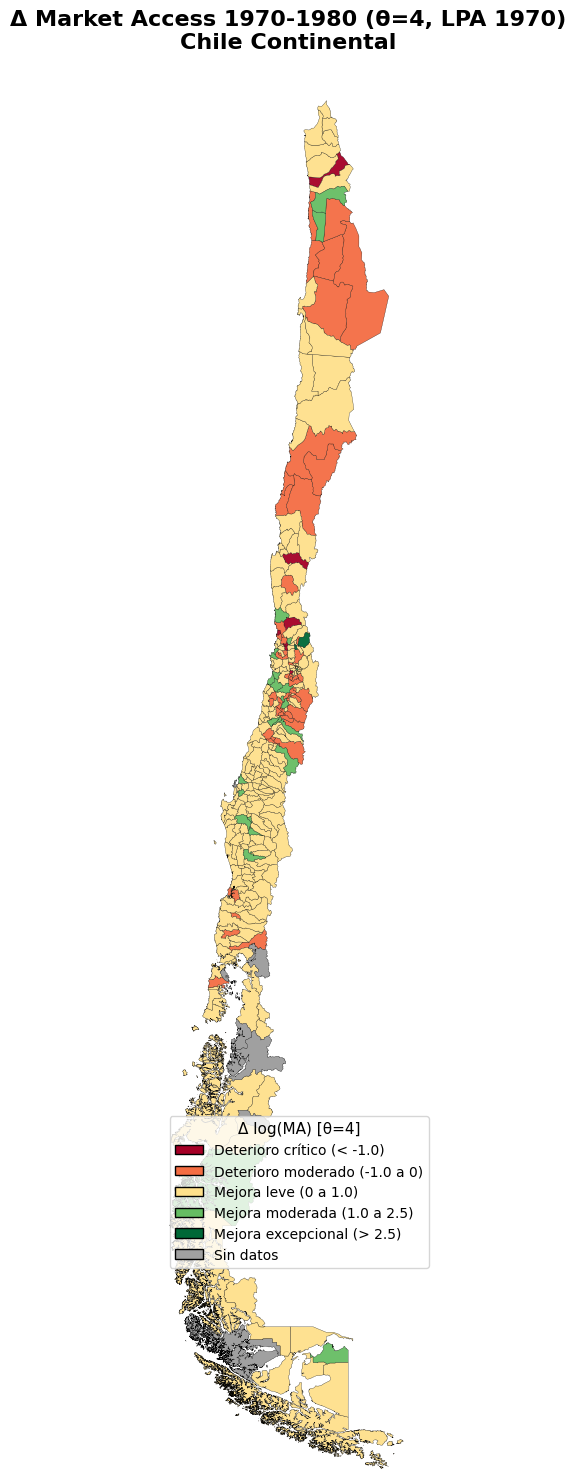

✓ Mapa guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapa_theta_4_70_80_comunas1970_Nacional.jpg


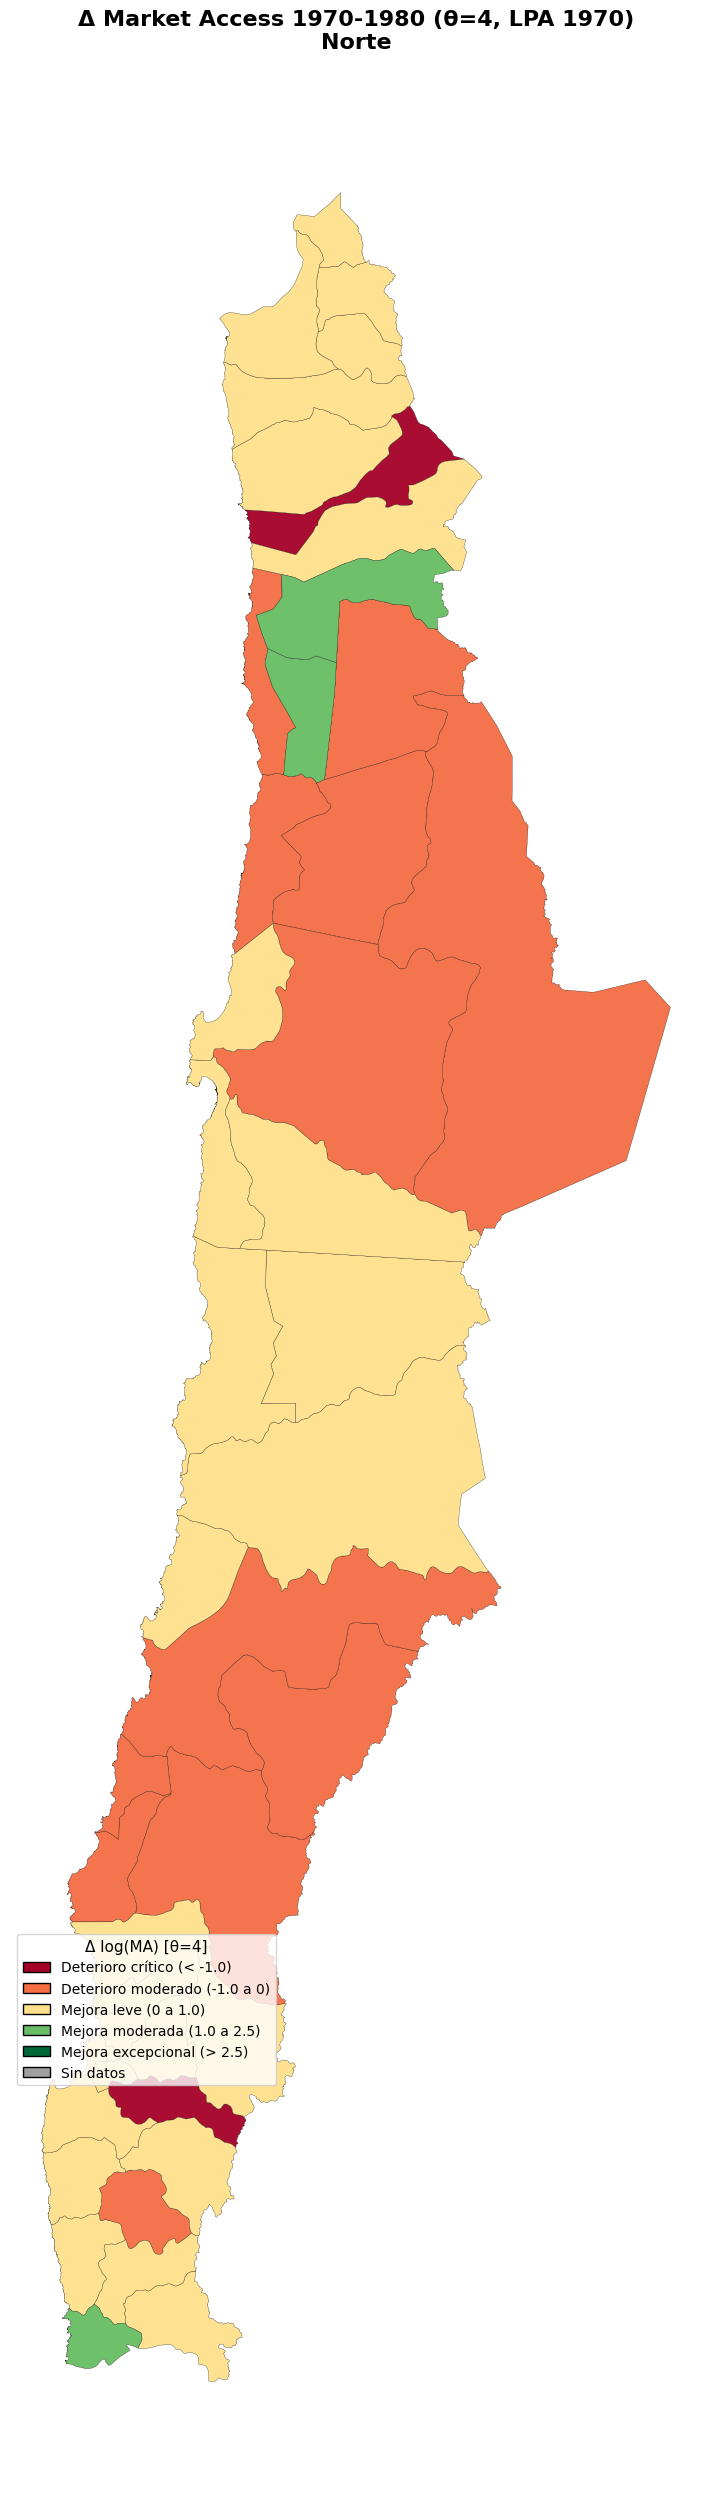

✓ Mapa guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapa_theta_4_70_80_comunas1970_Norte.jpg


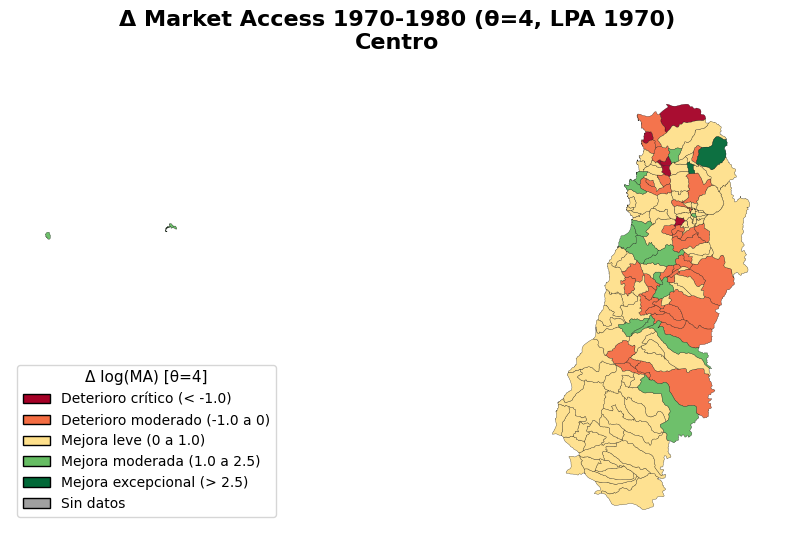

✓ Mapa guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapa_theta_4_70_80_comunas1970_Centro.jpg


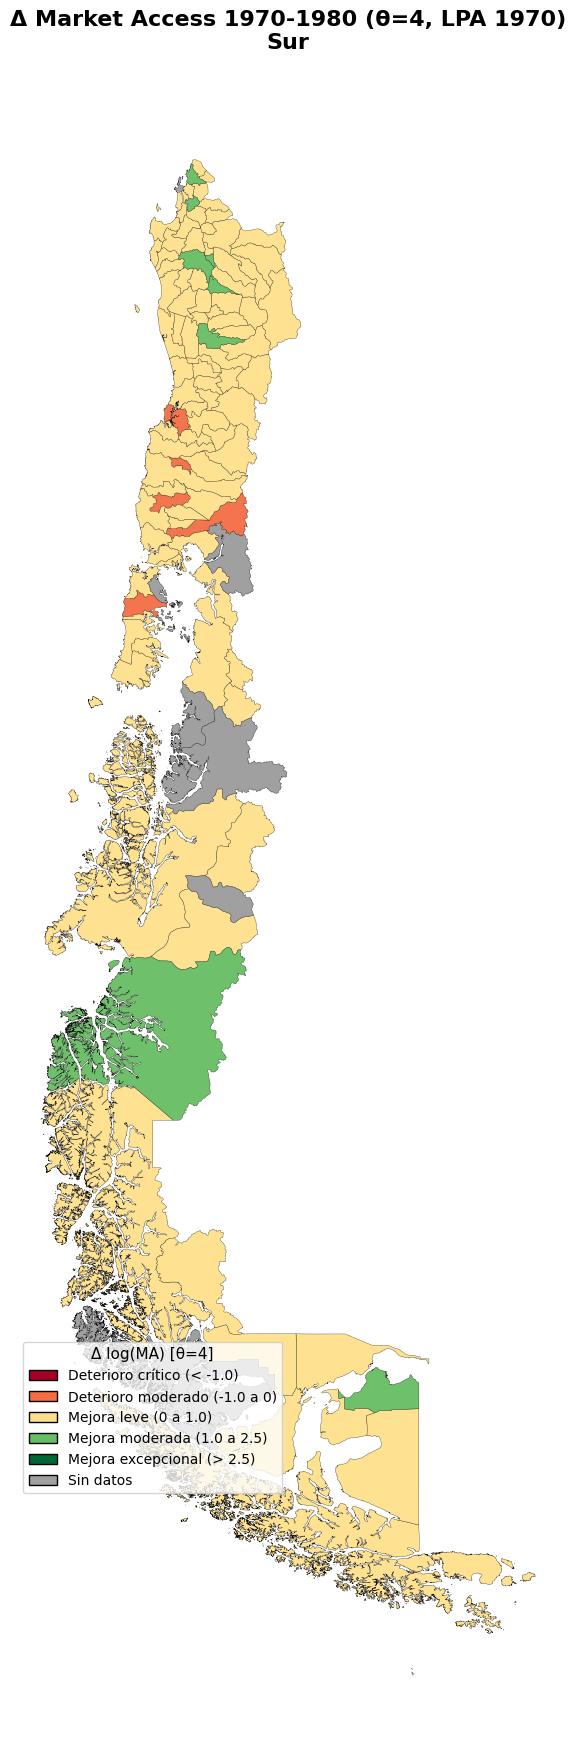

✓ Mapa guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapa_theta_4_70_80_comunas1970_Sur.jpg


In [ ]:
##MAPA NACIONAL Y REGIONALES THETA = 4 

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import pandas as pd
import os
import unicodedata, re


# Aseguramos los alias correctos para que Aysén y Coyhaique no se pierdan
SPELLING_ALIASES_LOCAL = {
    'AYSEN': 'AISEN',
    'COYHAIQUE': 'COIHAIQUE',
    'TREHUACO': 'TREGUACO',
    'PAIHUANO': 'PAIGUANO',
}

def normalizar_local(txt):
    if pd.isna(txt): return None
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'\s+', ' ', txt).strip()
    return SPELLING_ALIASES_LOCAL.get(txt, txt)

# Construimos el diccionario de comunas madre-hija localmente
mapping_path = '/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/mapping_1970_2024.csv'
hija_a_madre_local = {}
if os.path.exists(mapping_path):
    df_map = pd.read_csv(mapping_path)
    for _, row in df_map.iterrows():
        hija_a_madre_local[normalizar_local(row['daughter_2024'])] = normalizar_local(row['mother_1970'])

def get_zone_by_provincia(provincia):
    prov = str(provincia).upper()
    norte = ['TARAPACÁ', 'ANTOFAGASTA', 'ATACAMA', 'COQUIMBO']
    centro = ['ACONCAGUA', 'VALPARAÍSO', 'SANTIAGO', "O'HIGGINS", 'COLCHAGUA', 'CURICÓ', 'TALCA', 'MAULE', 'LINARES', 'ÑUBLE']
    if prov in norte: return 'Norte'
    if prov in centro: return 'Centro'
    return 'Sur'

# 2. CARGA DE DATOS Y MERGE

print("Cargando datos espaciales y de panel...")
PATH_SHP = '/Users/Angelo/Dropbox/DPA Historica/Comunas_1970.shp'
gdf_1970 = gpd.read_file(PATH_SHP, encoding='utf-8')

PATH_DTA = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad.dta'
df_dta = pd.read_stata(PATH_DTA)

# Normalizar y mapear
gdf_1970['comuna_norm'] = gdf_1970['COMUNA'].apply(normalizar_local)
df_dta['comuna_norm_dta'] = df_dta['comuna'].apply(normalizar_local)
gdf_1970['comuna_madre'] = gdf_1970['comuna_norm'].apply(lambda x: hija_a_madre_local.get(x, x))

if 'delta_log_ma_1970_1980' in df_dta.columns:
    df_dta.rename(columns={'delta_log_ma_1970_1980': 'delta_log_MA_1970_1980'}, inplace=True)

# Merge: Todo el shapefile mantiene sus geometrías
merged = gdf_1970.merge(df_dta, left_on='comuna_madre', right_on='comuna_norm_dta', how='left')

# Imprimimos explícitamente cuáles comunas no encontraron datos
faltantes = merged[merged['delta_log_MA_1970_1980'].isna()]['COMUNA'].tolist()
print(f"Comunas sin datos (aparecerán en gris): {faltantes}\n")

# =========================================================================
# 3. FUNCIÓN DE DIBUJO DE MAPA
# =========================================================================
def crear_mapa_theta_zona(gdf, columna, theta_val, zone_name, title, filename):
    gdf_temp = gdf.copy()
    
    col_comuna = 'COMUNA'
    comunas_excluir = ['ISLA DE PASCUA', 'RAPA NUI', 'JUAN FERNANDEZ', 'ANTARTICA', 'LA ANTÁRTICA']
    mask_continental = ~gdf_temp[col_comuna].str.upper().isin(comunas_excluir)
    gdf_temp = gdf_temp[mask_continental]

    gdf_temp['zona'] = gdf_temp['PROVINCIA'].apply(get_zone_by_provincia)

    if zone_name != 'Nacional':
        gdf_temp = gdf_temp[gdf_temp['zona'] == zone_name]

    if len(gdf_temp) == 0:
        return

    # Categorías
    bins_extremos = [-np.inf, -1.0, 0, 1.0, 2.5, np.inf]
    colores_extremos = ['#a50026', '#f46d43', '#fee08b', '#66bd63', '#006837']
    labels_extremos = [
        'Deterioro crítico (< -1.0)',
        'Deterioro moderado (-1.0 a 0)',
        'Mejora leve (0 a 1.0)',
        'Mejora moderada (1.0 a 2.5)',
        'Mejora excepcional (> 2.5)'
    ]
    gdf_temp['categoria'] = pd.cut(gdf_temp[columna], bins=bins_extremos, labels=False, include_lowest=True)
    
    if zone_name == 'Nacional':
        fig_width, fig_height = 10, 18
    else:
        bounds = gdf_temp.total_bounds
        width = bounds[2] - bounds[0]
        height = bounds[3] - bounds[1]
        aspect_ratio = width / height if height != 0 else 1
        fig_width = 10
        fig_height = max(fig_width / aspect_ratio, 10)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Dibujar las que sí tienen color
    for cat_idx, color in enumerate(colores_extremos):
        mask = gdf_temp['categoria'] == cat_idx
        if not gdf_temp[mask].empty:
            gdf_temp[mask].plot(ax=ax, color=color, edgecolor='black', linewidth=0.2, alpha=0.95)
            
    # Dibujar explícitamente el SIN DATOS en GRIS OSCURO (#a0a0a0)
    mask_null = (gdf_temp[columna].isna()) | (gdf_temp['categoria'].isna())
    if not gdf_temp[mask_null].empty:
        gdf_temp[mask_null].plot(ax=ax, color='#a0a0a0', edgecolor='black', linewidth=0.2)
    
    if zone_name == 'Nacional':
        ax.set_xlim([-76.0, -66.0])
        ax.set_ylim([-56.0, -17.0])
    
    patches = [mpatches.Patch(facecolor=c, edgecolor='black', label=l) for c, l in zip(colores_extremos, labels_extremos)]
    patches.append(mpatches.Patch(facecolor='#a0a0a0', edgecolor='black', label='Sin datos'))
    ax.legend(handles=patches, loc='center left', bbox_to_anchor=(0.0, 0.2), fontsize=10, title=f'Δ log(MA) [θ={theta_val}]', title_fontsize=11)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.axis('off')
    
    try:
        out_dir = PATH_OUT_DIR
    except NameError:
        out_dir = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/'
        os.makedirs(out_dir, exist_ok=True)
        
    out_path = os.path.join(out_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()
    print(f"✓ Mapa guardado: {out_path}")

# =========================================================================
# 4. BUCLE DE MAPAS
# =========================================================================
zonas_a_graficar = ['Nacional', 'Norte', 'Centro', 'Sur']

for zone_name in zonas_a_graficar:
    title = 'Δ Market Access 1970-1980 (θ=4, LPA 1970)\nChile Continental' if zone_name == 'Nacional' else f'Δ Market Access 1970-1980 (θ=4, LPA 1970)\n{zone_name}'
    filename = f'mapa_theta_4_70_80_comunas1970_{zone_name}.jpg'
    crear_mapa_theta_zona(merged, 'delta_log_MA_1970_1980', 4, zone_name, title, filename)




✓ Mapa guardado: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapa_theta_1_70_80_comunas1970.jpg
  Pérdida Máx: -0.2210, Ganancia Máx: 1.0854


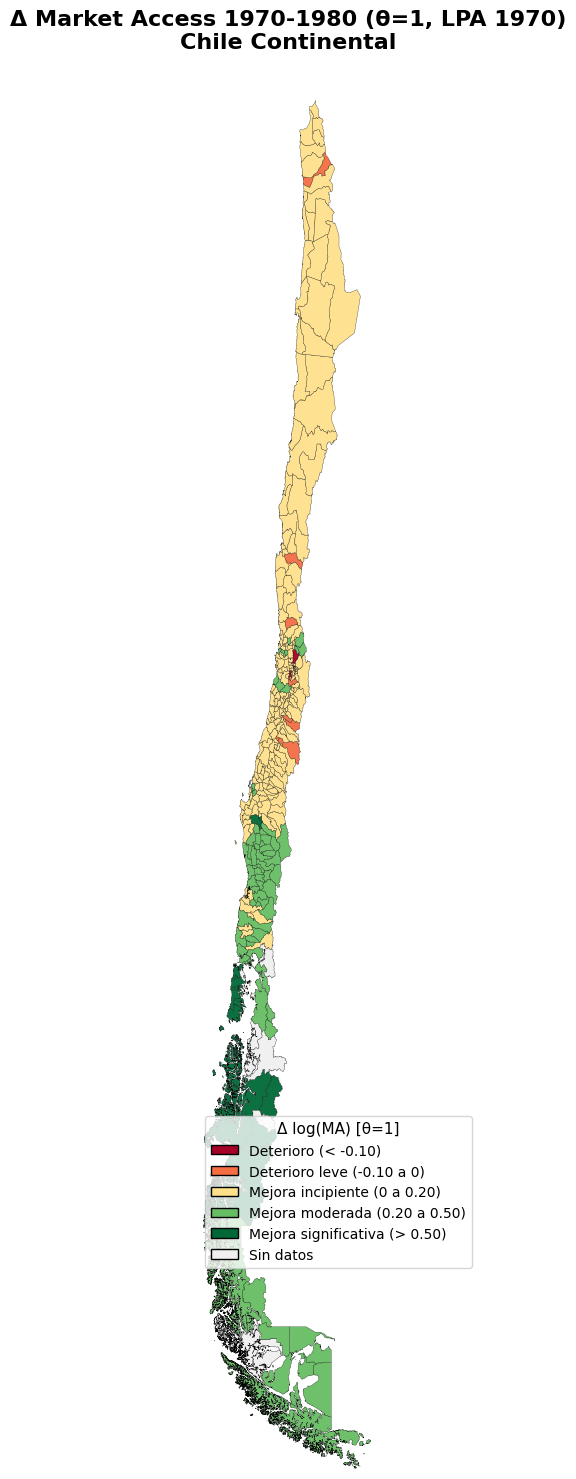

In [21]:
### CELDA D: MAPA NACIONAL THETA = 1 (SOLO CHILE CONTINENTAL) ###

def crear_mapa_theta1(gdf, columna, theta_val, title, filename):
    # 1. Crear copia y excluir islas oceánicas y Antártica
    gdf_temp = gdf.copy()
    
    # Buscar cuál es la columna de nombre de comuna en tu GeoDataFrame
    col_comuna = None
    for col in ['comuna', 'NOM_COM', 'COMUNA', 'comuna_norm']:
        if col in gdf_temp.columns:
            col_comuna = col
            break
            
    if col_comuna:
        comunas_excluir = ['ISLA DE PASCUA', 'RAPA NUI', 'JUAN FERNANDEZ', 'ANTARTICA']
        mask_continental = ~gdf_temp[col_comuna].str.upper().isin(comunas_excluir)
        gdf_temp = gdf_temp[mask_continental]
        
    # 2. Configurar categorías específicas para Theta=1
    bins = [-np.inf, -0.10, 0, 0.20, 0.50, np.inf]
    colores = ['#a50026', '#f46d43', '#fee08b', '#66bd63', '#006837']
    labels = [
        'Deterioro (< -0.10)',
        'Deterioro leve (-0.10 a 0)',
        'Mejora incipiente (0 a 0.20)',
        'Mejora moderada (0.20 a 0.50)',
        'Mejora significativa (> 0.50)'
    ]
    
    gdf_temp['categoria'] = pd.cut(gdf_temp[columna], bins=bins, labels=False, include_lowest=True)
    
    # 3. Dibujar
    fig, ax = plt.subplots(figsize=(10, 18))
    for cat_idx, color in enumerate(colores):
        mask = gdf_temp['categoria'] == cat_idx
        if not gdf_temp[mask].empty:
            gdf_temp[mask].plot(ax=ax, color=color, edgecolor='black', linewidth=0.2, alpha=0.95)
    
    mask_null = (gdf_temp[columna].isna()) | (gdf_temp['categoria'].isna())
    if not gdf_temp[mask_null].empty:
        gdf_temp[mask_null].plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=0.2)
    
    # 4. Forzar encuadre estricto a Chile Continental
    ax.set_xlim([-76.0, -66.0])
    ax.set_ylim([-56.0, -17.0])
    
    # 5. Leyenda y detalles
    patches = [mpatches.Patch(facecolor=c, edgecolor='black', label=l) for c, l in zip(colores, labels)]
    patches.append(mpatches.Patch(facecolor='#f0f0f0', edgecolor='black', label='Sin datos'))
    ax.legend(handles=patches, loc='center left', bbox_to_anchor=(0.0, 0.2), fontsize=10, 
              title=f'Δ log(MA) [θ={theta_val}]', title_fontsize=11)
              
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.axis('off')
    
    # Guardar
    out_path = os.path.join(PATH_OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f"✓ Mapa guardado: {out_path}")
    print(f"  Pérdida Máx: {gdf_temp[columna].min():.4f}, Ganancia Máx: {gdf_temp[columna].max():.4f}")
    plt.show()

# Ejecución
crear_mapa_theta1(
    merged, 'delta_70_80_th_1', 1,
    'Δ Market Access 1970-1980 (θ=1, LPA 1970)\nChile Continental',
    'mapa_theta_1_70_80_comunas1970.jpg'
)


✅ 27 comunas encontradas.
📸 Guardado.


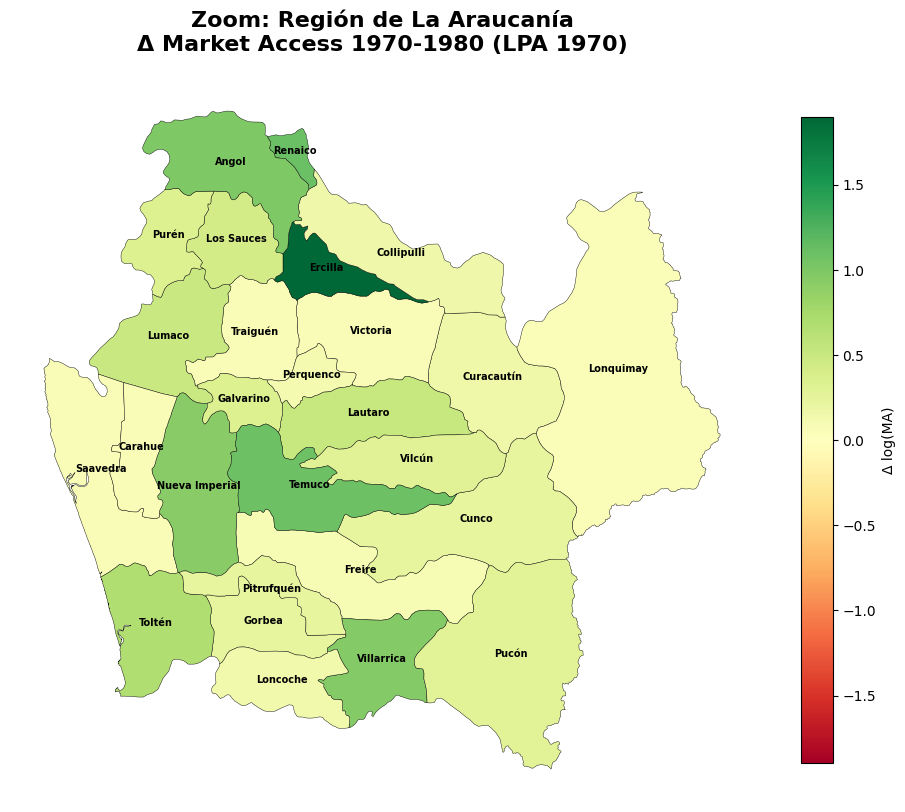

In [70]:
comunas_araucania = [
    'TEMUCO', 'CARAHUE', 'CHOLCHOL', 'CUNCO', 'CURARREHUE', 'FREIRE',
    'GALVARINO', 'GORBEA', 'LAUTARO', 'LONCOCHE', 'MELIPEUCO',
    'NUEVA IMPERIAL', 'PADRE LAS CASAS', 'PERQUENCO', 'PITRUFQUEN',
    'PUCON', 'SAAVEDRA', 'TEODORO SCHMIDT', 'TOLTEN', 'VILCUN',
    'VILLARRICA', 'ANGOL', 'COLLIPULLI', 'CURACAUTIN', 'ERCILLA',
    'LONQUIMAY', 'LOS SAUCES', 'LUMACO', 'PUREN', 'RENAICO',
    'TRAIGUEN', 'VICTORIA'
]
comunas_ar_norm = [normalizar(c) for c in comunas_araucania]
gdf_zoom = merged[merged['norm_name'].isin(comunas_ar_norm)].copy()

if gdf_zoom.empty:
    print("❌ No se encontraron comunas de la Araucanía.")
else:
    print(f"✅ {len(gdf_zoom)} comunas encontradas.")
    col_plot = 'delta_log_MA_1970_1980'
    limit = max(abs(gdf_zoom[col_plot].dropna().min()), abs(gdf_zoom[col_plot].dropna().max()))
    
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_zoom.plot(column=col_plot, cmap='RdYlGn', vmin=-limit, vmax=limit,
                  legend=True, ax=ax, edgecolor='black', linewidth=0.3,
                  legend_kwds={'label': 'Δ log(MA)', 'shrink': 0.7},
                  missing_kwds={'color': 'lightgrey'})
    
    # Etiquetas con nombre del shapefile (COMUNA original)
    for _, row in gdf_zoom.iterrows():
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        nombre = row['COMUNA'] if pd.notna(row['COMUNA']) else ''
        ax.text(x, y, str(nombre).title(), fontsize=7, ha='center', fontweight='bold')
    
    ax.set_title("Zoom: Región de La Araucanía\nΔ Market Access 1970-1980 (LPA 1970)", fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.savefig(PATH_OUT_DIR + 'zoom_araucania_70_80_comunas1970.jpg', dpi=300, bbox_inches='tight')
    print(f"📸 Guardado.")
    plt.show()


✅ 34 comunas de la RM encontradas.
📸 Guardado.


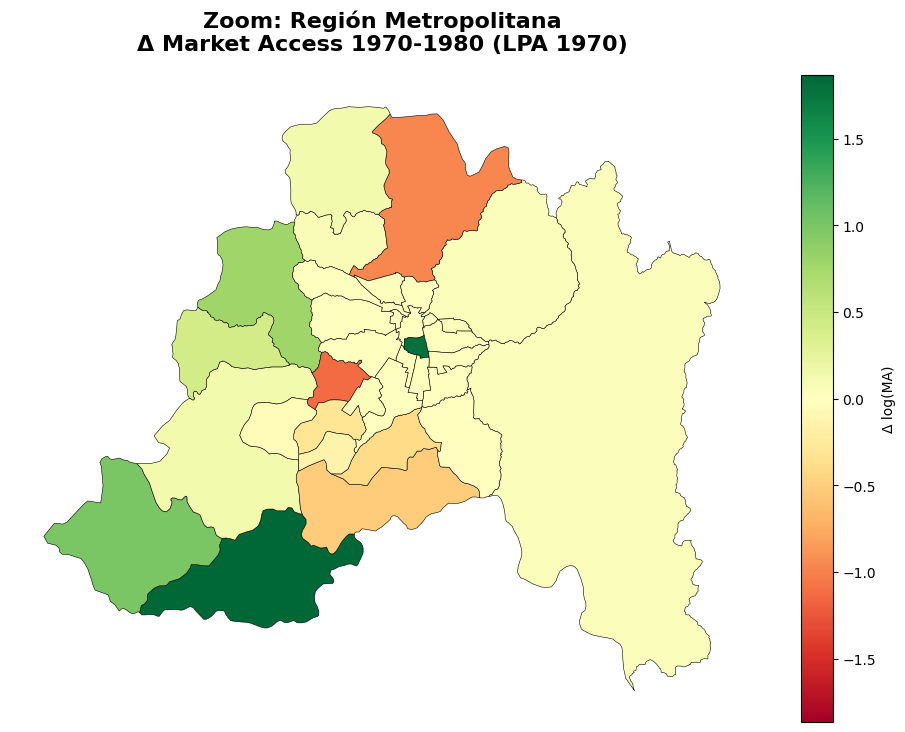

In [69]:

comunas_rm = [
    'SANTIAGO', 'CERRILLOS', 'CERRO NAVIA', 'CONCHALI', 'EL BOSQUE',
    'ESTACION CENTRAL', 'HUECHURABA', 'INDEPENDENCIA', 'LA CISTERNA',
    'LA FLORIDA', 'LA GRANJA', 'LA PINTANA', 'LA REINA', 'LAS CONDES',
    'LO BARNECHEA', 'LO ESPEJO', 'LO PRADO', 'MACUL', 'MAIPU',
    'NUNOA', 'PEDRO AGUIRRE CERDA', 'PENALOLEN', 'PROVIDENCIA',
    'PUDAHUEL', 'QUILICURA', 'QUINTA NORMAL', 'RECOLETA', 'RENCA',
    'SAN JOAQUIN', 'SAN MIGUEL', 'SAN RAMON', 'VITACURA', 'PUENTE ALTO',
    'PIRQUE', 'SAN JOSE DE MAIPO', 'SAN BERNARDO', 'BUIN', 'PAINE',
    'CALERA DE TANGO', 'COLINA', 'LAMPA', 'TILTIL', 'MELIPILLA',
    'CURACAVI', 'MARIA PINTO', 'SAN PEDRO', 'ALHUE', 'TALAGANTE',
    'PEÑAFLOR', 'ISLA DE MAIPO', 'EL MONTE', 'PADRE HURTADO',
    'BARRANCAS'
]
comunas_rm_norm = [normalizar(c) for c in comunas_rm]
gdf_rm_zoom = merged[merged['norm_name'].isin(comunas_rm_norm)].copy()

if gdf_rm_zoom.empty:
    print("❌ No se encontraron las comunas de la RM.")
else:
    print(f"✅ {len(gdf_rm_zoom)} comunas de la RM encontradas.")
    col_mapa = 'delta_log_MA_1970_1980'
    val_min, val_max = gdf_rm_zoom[col_mapa].dropna().min(), gdf_rm_zoom[col_mapa].dropna().max()
    limit = max(abs(val_min), abs(val_max)) if pd.notna(val_min) else 1
    
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_rm_zoom.plot(column=col_mapa, cmap='RdYlGn', vmin=-limit, vmax=limit,
                     legend=True, ax=ax, edgecolor='black', linewidth=0.4,
                     legend_kwds={'label': 'Δ log(MA)', 'shrink': 0.7},
                     missing_kwds={'color': 'lightgrey'})
    
    # SIN etiquetas en RM
    
    ax.set_title("Zoom: Región Metropolitana\nΔ Market Access 1970-1980 (LPA 1970)", fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.savefig(PATH_OUT_DIR + 'zoom_rm_70_80_comunas1970.jpg', dpi=300, bbox_inches='tight')
    print(f"📸 Guardado.")
    plt.show()


✅ 9 comunas/polígonos de Antofagasta encontrados.
📸 Guardado.


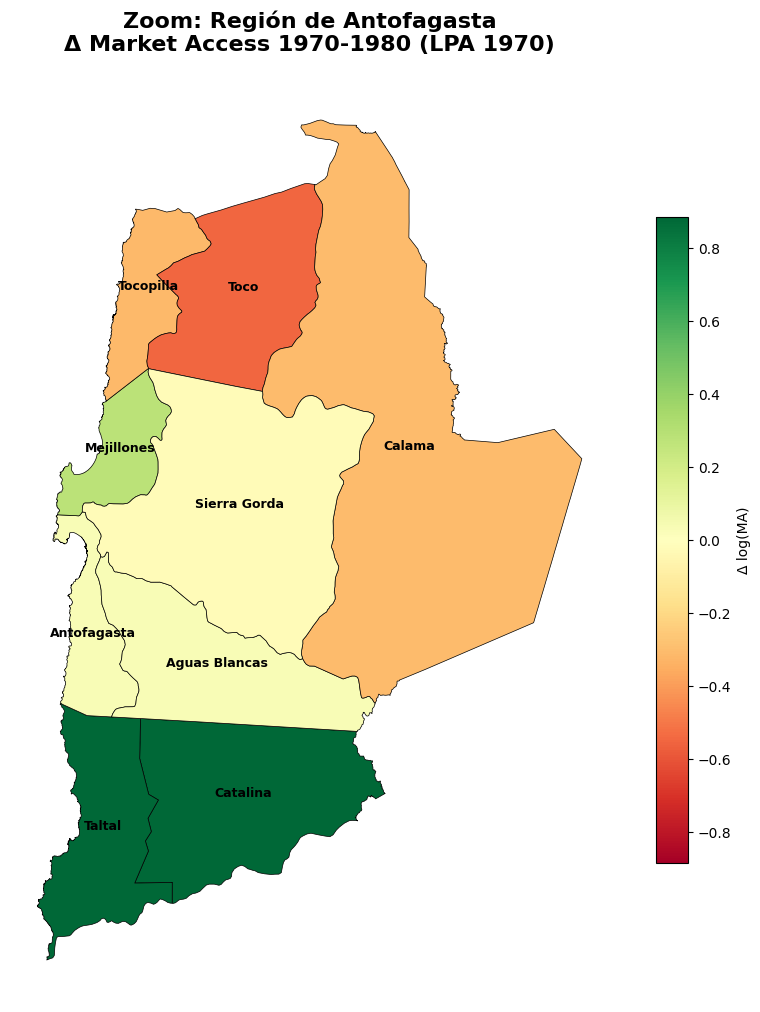

In [68]:
comunas_antofagasta = [
    'ANTOFAGASTA', 'AGUAS BLANCAS', 'CALAMA', 'MARIA ELENA', 'TOCO',
    'MEJILLONES', 'OLLAGUE', 'SAN PEDRO DE ATACAMA', 'SIERRA GORDA',
    'TALTAL', 'CATALINA', 'TOCOPILLA'
]
comunas_anto_norm = [normalizar(c) for c in comunas_antofagasta]
gdf_anto_zoom = merged[merged['norm_name'].isin(comunas_anto_norm)].copy()

if gdf_anto_zoom.empty:
    print("❌ No se encontraron las comunas de Antofagasta.")
else:
    print(f"✅ {len(gdf_anto_zoom)} comunas/polígonos de Antofagasta encontrados.")
    col_mapa = 'delta_log_MA_1970_1980'
    val_min, val_max = gdf_anto_zoom[col_mapa].dropna().min(), gdf_anto_zoom[col_mapa].dropna().max()
    limit = max(abs(val_min), abs(val_max)) if pd.notna(val_min) else 1
    
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_anto_zoom.plot(column=col_mapa, cmap='RdYlGn', vmin=-limit, vmax=limit,
                       legend=True, ax=ax, edgecolor='black', linewidth=0.5,
                       legend_kwds={'label': 'Δ log(MA)', 'orientation': 'vertical', 'shrink': 0.7},
                       missing_kwds={'color': 'lightgrey'})
    
    # Etiquetas con nombre del shapefile (nombre original 1970)
    for _, row in gdf_anto_zoom.iterrows():
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        nombre = row['COMUNA'] if pd.notna(row['COMUNA']) else ''
        ax.text(x, y, str(nombre).title(), fontsize=9, ha='center', fontweight='bold')
    
    ax.set_title("Zoom: Región de Antofagasta\nΔ Market Access 1970-1980 (LPA 1970)", fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.savefig(PATH_OUT_DIR + 'zoom_antofagasta_70_80_comunas1970.jpg', dpi=300, bbox_inches='tight')
    print(f"📸 Guardado.")
    plt.show()
